In [2]:
from laboneq_applications.contrib.experiments import amplitude_rabi_chevron
from laboneq_applications.qpu_types.tunable_transmon import TunableTransmonQubit, TunableTransmonOperations


from laboneq.simple import *
from laboneq.dsl.quantum import QPU

import numpy as np
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

In [3]:
number_of_qubits = 1

from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor

descriptor = generate_descriptor(
    pqsc=["DEV10001"],
    shfqc_6=["DEV12001"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
)
setup = DeviceSetup.from_descriptor(descriptor, "localhost")

/opt/homebrew/anaconda3/envs/pico-thermo/lib/python3.13/site-packages/laboneq/dsl/device/_device_setup_generator.py:262: FutureWarning: Explicit ZSYNCS connections are deprecated and currently ignored. Remove them from the device setup descriptor. This will be a hard error in a future version.
  modifier.add_connection(


In [4]:
qubits = TunableTransmonQubit.from_device_setup(setup)

for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: q0
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')


In [6]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 1e-6
    q.parameters.readout_range_out = -25
    q.parameters.readout_lo_frequency = 7.4e9

qubits[0].parameters.drive_lo_frequency = 6.4e9
qubits[0].parameters.resonance_frequency_ge = 6.3e9
qubits[0].parameters.resonance_frequency_ef = 6.0e9
qubits[0].parameters.readout_resonator_frequency = 7.0e9

In [7]:
qops = TunableTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)

In [8]:
session = Session(setup)
session.connect(do_emulation=True)  # do_emulation=False when at a real setup

[2026.08.25 12:15:14.726] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/qubit-thermometry_v2.0/laboneq_output/log
[2026.08.25 12:15:14.728] INFO    VERSION: laboneq 26.4.0
[2026.08.25 12:15:14.730] INFO    Connecting to data server at localhost:8004
[2026.08.25 12:15:14.731] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.08.25 12:15:14.734] INFO    Configuring the device setup
[2026.08.25 12:15:14.760] INFO    The device setup is configured


In [9]:
options = amplitude_rabi_chevron.experiment_workflow.options()
workflow.show_fields(options)

Option Fields
acquisition_type:
	Description: Acquisition type to use for the experiment.
	Classes and Defaults: [('TuneupExperimentOptions', AcquisitionType.INTEGRATION)], 

active_reset:
	Description: Whether to use active reset.
	Classes and Defaults: [('TuneupExperimentOptions', False)], 

active_reset_repetitions:
	Description: The number of times to repeat the active resets.
	Classes and Defaults: [('TuneupExperimentOptions', 1)], 

active_reset_states:
	Description: The qubit states to actively reset.
	Classes and Defaults: [('TuneupExperimentOptions', 'ge')], 

averaging_mode:
	Description: Averaging mode to use for the experiment.
	Classes and Defaults: [('TuneupExperimentOptions', AveragingMode.CYCLIC)], 

cal_states:
	Description: The states to prepare in the calibration traces.
	Classes and Defaults: [('TuneupExperimentOptions', 'ge'), ('CalculateQubitPopulation2DOptions', 'ge'), ('PlotPopulationRabiChevronOptions', 'ge')], 

close_figures:
	Description: Whether to close th

[2026.08.25 12:15:54.854] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 12:15:54.855] INFO      Workflow 'amplitude_rabi_chevron': execution started at 2026-08-25            
[2026.08.25 12:15:54.856] INFO      09:15:54.854402Z                                                              
[2026.08.25 12:15:54.856] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 12:15:54.857] INFO    Task 'temporary_qpu': started at 2026-08-25 09:15:54.857203Z
[2026.08.25 12:15:54.858] INFO    Task 'temporary_qpu': ended at 2026-08-25 09:15:54.857898Z
[2026.08.25 12:15:54.858] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 12:15:54.858] INFO    09:15:54.858491Z
[2026.08.25 12:15:54.859] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 09:15:54.859298Z
[2026.08.25 12:15:54.859] INFO    Task 'create_experiment': started at 2026-08-25 09:

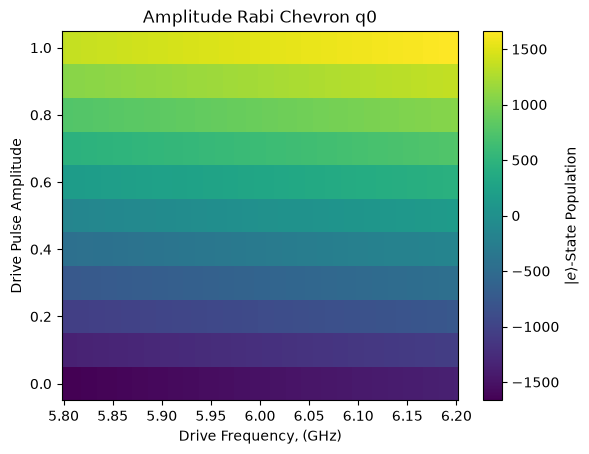

In [11]:
# our qubits live here in the demo setup:
qubits = qpu.quantum_elements

exp_workflow = amplitude_rabi_chevron.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=qubits[0].uid,
    frequencies=np.linspace(5.8e9, 6.2e9, 101),
    amplitudes=np.linspace(0, 1, 11),
    options=options,
)

workflow_results = exp_workflow.run()

In [ ]:
compiled_experiment = workflow_results.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6)